# Solar Illumination Planning

Solar geometry is critical for airborne remote sensing — it determines when
sufficient illumination is available, affects data quality, and constrains
the daily time window for data collection. This notebook demonstrates HyPlan's
`sun` module for planning around solar conditions.

We cover:

1. Computing solar azimuth at a specific time
2. Solar position throughout the day (azimuth and elevation at increments)
3. Visualizing solar tracks with polar plots
4. Finding daily time windows for solar elevation thresholds
5. Multi-day threshold tables for campaign scheduling
6. Comparing solar windows across different sites and seasons

In [1]:
from datetime import datetime, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from hyplan.sun import (
    solar_azimuth,
    solar_position_increments,
    solar_threshold_times,
    plot_solar_positions,
)

## 1. Solar Azimuth at a Specific Time

`solar_azimuth()` returns the sun's compass bearing (degrees from north) at a given
location and UTC datetime. This is needed for glint calculations and shadow analysis.

In [2]:
# Monterey Bay, California
lat, lon = 36.8, -121.9

# Solar azimuth at noon local time (UTC-7) on July 15
dt = datetime(2025, 7, 15, 19, 0, 0)  # 12:00 PM Pacific = 19:00 UTC
az = solar_azimuth(lat, lon, dt)
print(f"Solar azimuth at {dt} UTC: {az:.2f} deg")

# Track azimuth across several hours
print("\nHourly solar azimuths:")
for hour_utc in range(16, 24):
    dt_h = datetime(2025, 7, 15, hour_utc, 0, 0)
    az_h = solar_azimuth(lat, lon, dt_h)
    local_hour = hour_utc - 7
    print(f"  {local_hour:2d}:00 local ({hour_utc:2d}:00 UTC) -> azimuth = {az_h:.1f} deg")

Solar azimuth at 2025-07-15 19:00:00 UTC: 128.89 deg

Hourly solar azimuths:
   9:00 local (16:00 UTC) -> azimuth = 87.1 deg
  10:00 local (17:00 UTC) -> azimuth = 96.4 deg
  11:00 local (18:00 UTC) -> azimuth = 108.7 deg
  12:00 local (19:00 UTC) -> azimuth = 128.9 deg
  13:00 local (20:00 UTC) -> azimuth = 168.2 deg
  14:00 local (21:00 UTC) -> azimuth = 216.3 deg
  15:00 local (22:00 UTC) -> azimuth = 243.6 deg
  16:00 local (23:00 UTC) -> azimuth = 258.5 deg


## 2. Solar Position Throughout the Day

`solar_position_increments()` returns a table of solar azimuth and elevation at
regular intervals, filtered to times when the elevation exceeds a minimum threshold.
This is the primary tool for understanding the daily solar geometry at a site.

In [3]:
# Solar positions on July 15 when elevation > 30 deg (good illumination)
df_positions = solar_position_increments(
    lat, lon,
    date="2025-07-15",
    min_elevation=30,
    timezone_offset=-7,   # Pacific time
    increment="10min",    # 10-minute intervals (default)
)
print(f"Time window with solar elevation > 30 deg: {len(df_positions)} intervals")
print(f"First: {df_positions.iloc[0]['Time']}, Last: {df_positions.iloc[-1]['Time']}")
df_positions

Time window with solar elevation > 30 deg: 54 intervals
First: 17:00:00, Last: 16:50:00


,Time,Azimuth,Elevation
0,17:00:00,269.035202,39.046422
1,17:10:00,270.537456,37.045720
2,17:20:00,272.001649,35.045641
3,17:30:00,273.434041,33.047492
4,17:40:00,274.840211,31.052506
5,08:50:00,85.649854,31.553865
6,09:00:00,87.067537,33.548948
7,09:10:00,88.513232,35.546779
8,09:20:00,89.992725,37.546093
9,09:30:00,91.512516,39.545546


## 3. Polar Plot of Solar Positions

`plot_solar_positions()` creates a polar plot showing the sun's track across the
sky, with azimuth on the angular axis and zenith angle (90 - elevation) on the
radial axis. This provides an intuitive view of the solar geometry.

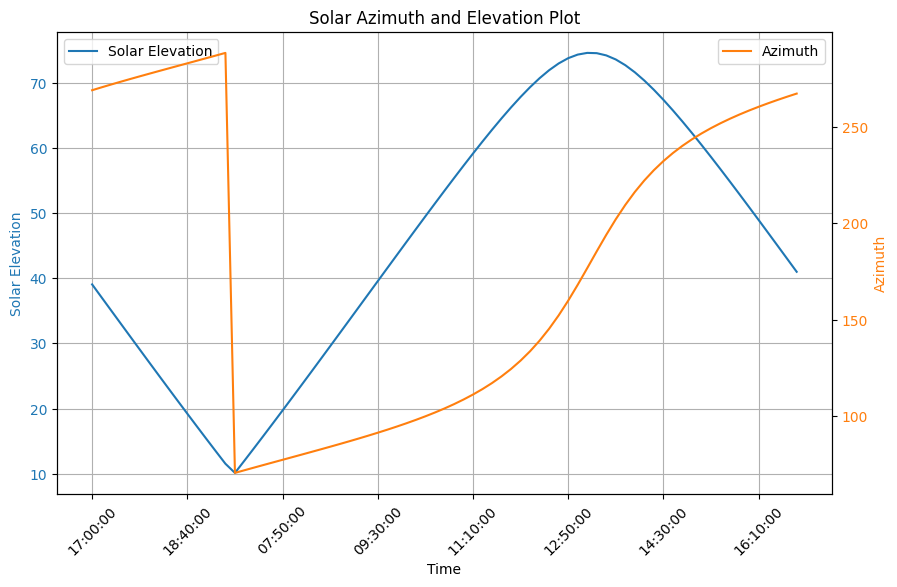

In [4]:
# Use a lower elevation threshold to see more of the day
df_full_day = solar_position_increments(
    lat, lon,
    date="2025-07-15",
    min_elevation=10,
    timezone_offset=-7,
)
plot_solar_positions(df_full_day)

## 4. Solar Threshold Times

`solar_threshold_times()` finds the exact times when the solar elevation crosses
specified thresholds over a date range. This is the key function for determining
daily data-collection windows.

For example, many imaging spectrometers require solar elevation between 35 and 55
degrees. The function returns the rise and set times for each threshold on each day.

In [5]:
# Daily threshold times for a two-week campaign window
# Thresholds: 35 deg (minimum for good data) and 55 deg (avoid steep sun angles)
df_thresholds = solar_threshold_times(
    lat, lon,
    start_date="2025-07-01",
    end_date="2025-07-14",
    thresholds=[35, 55],
    timezone_offset=-7,  # Pacific time
)
print("Daily solar threshold crossing times (local time):")
df_thresholds

Daily solar threshold crossing times (local time):


,Date,Rise_35,Rise_55,Set_55,Set_35
0,2025-07-01,09:02:00,10:42:00,15:41:00,17:22:00
1,2025-07-02,09:02:00,10:42:00,15:41:00,17:22:00
2,2025-07-03,09:02:00,10:43:00,15:41:00,17:22:00
3,2025-07-04,09:03:00,10:43:00,15:41:00,17:22:00
4,2025-07-05,09:03:00,10:44:00,15:41:00,17:21:00
5,2025-07-06,09:04:00,10:44:00,15:41:00,17:21:00
6,2025-07-07,09:04:00,10:45:00,15:41:00,17:21:00
7,2025-07-08,09:04:00,10:45:00,15:40:00,17:21:00
8,2025-07-09,09:05:00,10:46:00,15:40:00,17:21:00
9,2025-07-10,09:05:00,10:46:00,15:40:00,17:21:00


## 5. Visualizing Data-Collection Windows

Use the threshold times to compute and visualize the daily window duration
available for data collection.

/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_30535/1206065912.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_thresholds[set_col]) - pd.to_datetime(df_thresholds[rise_col])
/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_30535/1206065912.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_thresholds[set_col]) - pd.to_datetime(df_thresholds[rise_col])
/var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/ipykernel_30535/1206065912.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_thresholds[rise

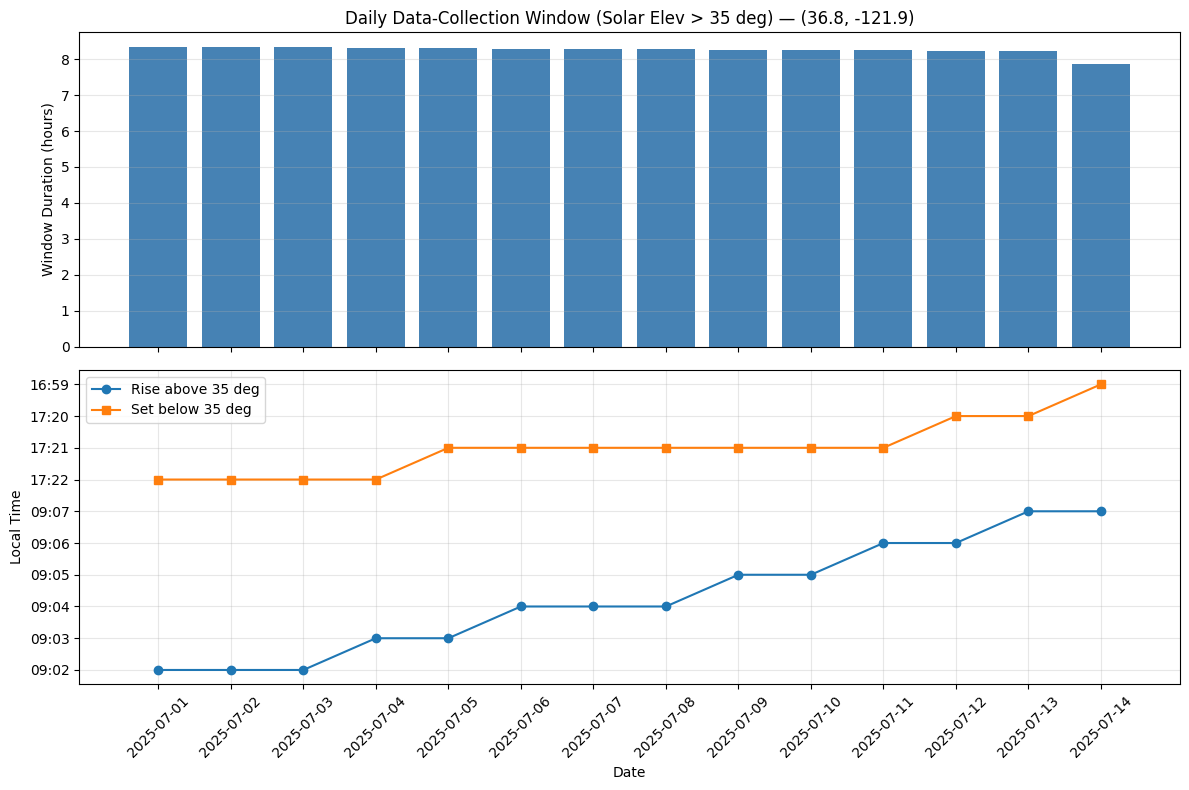

In [6]:
# Compute the data-collection window width using the 35-degree threshold
# The window is from Rise_35 to Set_35
rise_col = [c for c in df_thresholds.columns if c.startswith("Rise_35")][0]
set_col = [c for c in df_thresholds.columns if c.startswith("Set_35")][0]

df_thresholds["Window_hours"] = (
    pd.to_datetime(df_thresholds[set_col]) - pd.to_datetime(df_thresholds[rise_col])
).dt.total_seconds() / 3600

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Window duration per day
axes[0].bar(df_thresholds["Date"].astype(str), df_thresholds["Window_hours"], color="steelblue")
axes[0].set_ylabel("Window Duration (hours)")
axes[0].set_title(f"Daily Data-Collection Window (Solar Elev > 35 deg) — ({lat}, {lon})")
axes[0].grid(True, axis="y", alpha=0.3)

# Rise and set times
axes[1].plot(df_thresholds["Date"].astype(str),
             pd.to_datetime(df_thresholds[rise_col]).dt.strftime("%H:%M"),
             "o-", label="Rise above 35 deg")
axes[1].plot(df_thresholds["Date"].astype(str),
             pd.to_datetime(df_thresholds[set_col]).dt.strftime("%H:%M"),
             "s-", label="Set below 35 deg")
axes[1].set_ylabel("Local Time")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Comparing Sites and Seasons

Solar geometry varies dramatically with latitude and time of year. Compare
data-collection windows across different sites to help choose optimal campaign
timing and locations.

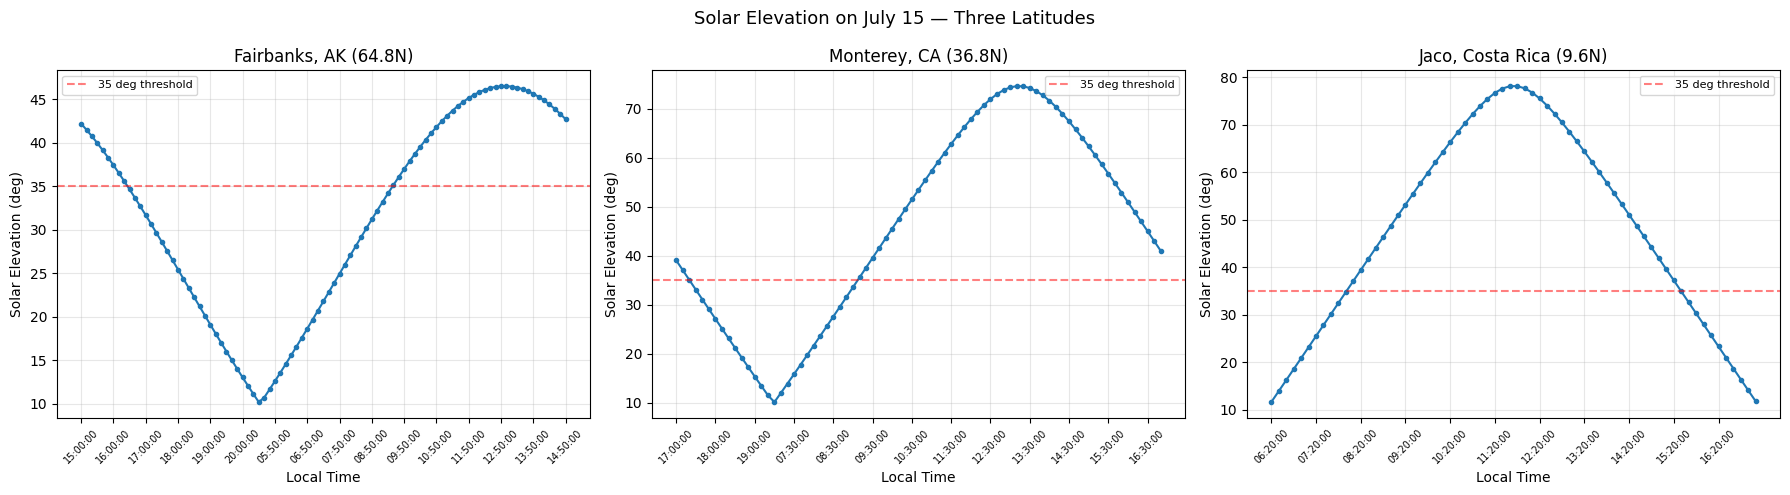

In [7]:
# Compare solar tracks at three different latitudes on the same day
sites = [
    ("Fairbanks, AK", 64.84, -147.72, -9),
    ("Monterey, CA", 36.8, -121.9, -7),
    ("Jaco, Costa Rica", 9.62, -84.82, -6),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, s_lat, s_lon, tz) in zip(axes, sites):
    df = solar_position_increments(s_lat, s_lon, "2025-07-15", min_elevation=10,
                                   timezone_offset=tz, increment="10min")
    ax.plot(df["Time"], df["Elevation"], "o-", markersize=3)
    ax.axhline(y=35, color="red", linestyle="--", alpha=0.5, label="35 deg threshold")
    ax.set_title(f"{name} ({s_lat:.1f}N)")
    ax.set_xlabel("Local Time")
    ax.set_ylabel("Solar Elevation (deg)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    # Show every 6th tick to avoid crowding
    ticks = ax.get_xticks()
    ax.set_xticks(ticks[::6])
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)

plt.suptitle("Solar Elevation on July 15 — Three Latitudes", fontsize=13)
plt.tight_layout()
plt.show()

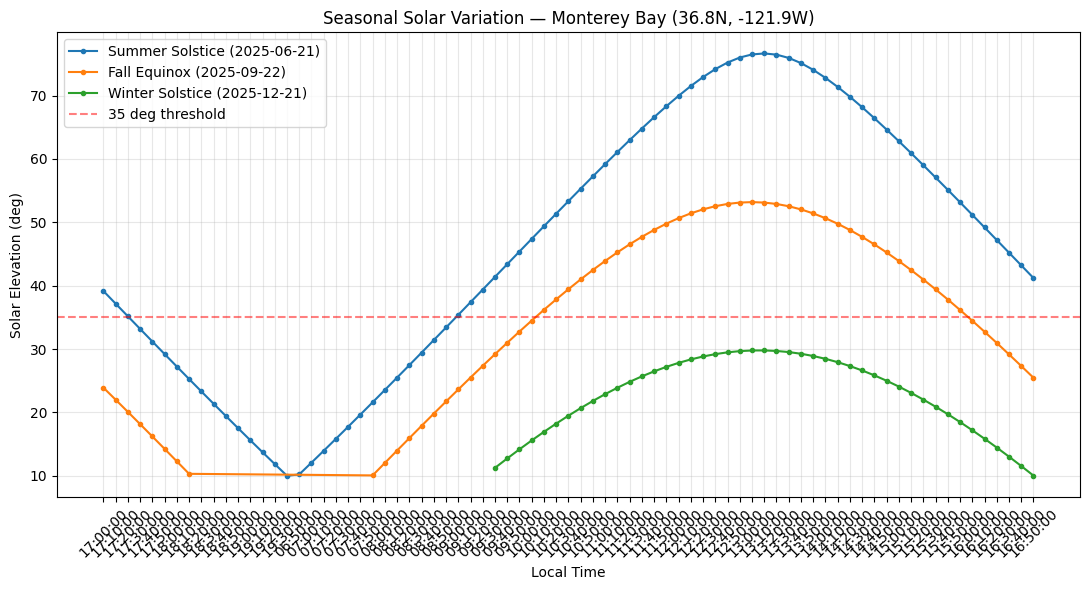

In [8]:
# Compare seasonal variation at Monterey: summer vs winter solstice vs equinox
dates = [
    ("Summer Solstice", "2025-06-21"),
    ("Fall Equinox", "2025-09-22"),
    ("Winter Solstice", "2025-12-21"),
]

fig, ax = plt.subplots(figsize=(11, 6))

for label, date in dates:
    df = solar_position_increments(lat, lon, date, min_elevation=10,
                                   timezone_offset=-7, increment="10min")
    ax.plot(df["Time"], df["Elevation"], "o-", markersize=3, label=f"{label} ({date})")

ax.axhline(y=35, color="red", linestyle="--", alpha=0.5, label="35 deg threshold")
ax.set_xlabel("Local Time")
ax.set_ylabel("Solar Elevation (deg)")
ax.set_title(f"Seasonal Solar Variation — Monterey Bay ({lat}N, {lon}W)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Multi-Day Campaign Planning

For a longer campaign, generate a threshold table spanning the entire deployment
period. This helps identify which days have the longest collection windows and
assists with scheduling flights, rest days, and logistics.

In [9]:
# Costa Rica coastal campaign — Feb 1 to Mar 7
# Thresholds: 35 deg (minimum) and 55 deg (maximum for avoiding steep angles)
cr_lat, cr_lon = 9.615, -84.82

df_campaign = solar_threshold_times(
    cr_lat, cr_lon,
    start_date="2025-02-01",
    end_date="2025-03-07",
    thresholds=[35, 55],
    timezone_offset=-6,  # Costa Rica time (CST)
)
print(f"Campaign: {len(df_campaign)} days")
print(f"Columns: {list(df_campaign.columns)}")
df_campaign.head(10)

Campaign: 35 days
Columns: ['Date', 'Rise_35', 'Rise_55', 'Set_55', 'Set_35']


,Date,Rise_35,Rise_55,Set_55,Set_35
0,2025-02-01,08:38:00,10:21:00,13:25:00,15:08:00
1,2025-02-02,08:38:00,10:20:00,13:27:00,15:08:00
2,2025-02-03,08:37:00,10:18:00,13:28:00,15:09:00
3,2025-02-04,08:37:00,10:17:00,13:29:00,15:10:00
4,2025-02-05,08:36:00,10:16:00,13:31:00,15:10:00
5,2025-02-06,08:36:00,10:15:00,13:32:00,15:11:00
6,2025-02-07,08:35:00,10:14:00,13:33:00,15:12:00
7,2025-02-08,08:35:00,10:13:00,13:34:00,15:12:00
8,2025-02-09,08:34:00,10:11:00,13:36:00,15:13:00
9,2025-02-10,08:34:00,10:10:00,13:37:00,15:13:00


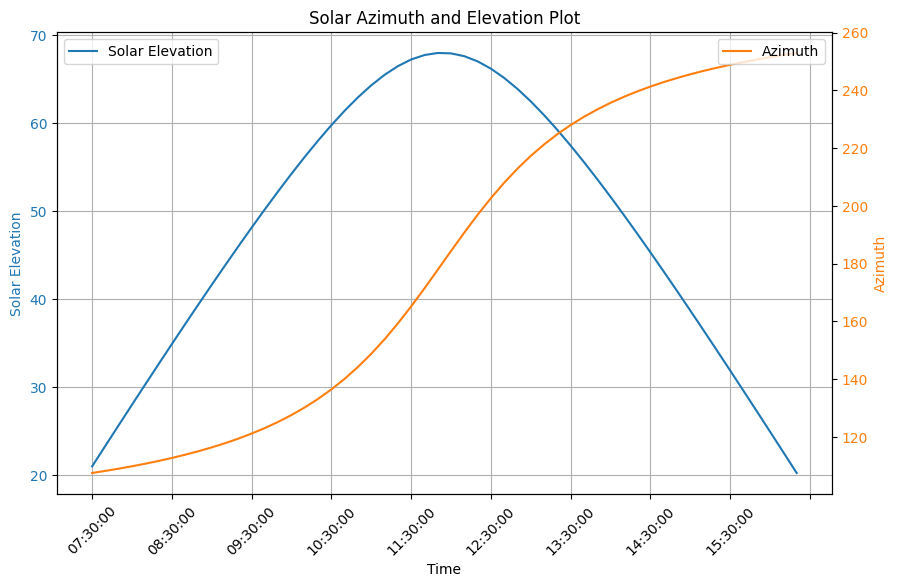

In [10]:
# Polar plot for a specific campaign day
df_cr_day = solar_position_increments(
    cr_lat, cr_lon,
    date="2025-02-15",
    min_elevation=20,
    timezone_offset=-6,
)
plot_solar_positions(df_cr_day)

## Summary

| Function | Purpose |
|----------|---------|
| `solar_azimuth(lat, lon, dt)` | Sun's compass bearing at a specific UTC time |
| `solar_position_increments(lat, lon, date, min_elevation, ...)` | Table of azimuth/elevation at regular intervals |
| `plot_solar_positions(df)` | Polar sky plot of the sun's track |
| `solar_threshold_times(lat, lon, start, end, thresholds, ...)` | Daily times when elevation crosses thresholds |

**Key parameters:**
- `timezone_offset` — Convert UTC results to local time for easier interpretation
- `min_elevation` — Filter to times with adequate illumination
- `increment` — Time step for position sampling (default "10min")
- `thresholds` — List of elevation angles to find crossing times for